# 02 - Preprocessing and Feature Experiments (Stage 4)
1. Duplicates + stratified split (before any fitting)
2. **Missing values** - Experiment A: simulated imputation error. Experiment B: effect on model performance.
3. **Outliers, feature engineering, feature selection, leakage** - one-factor-at-a-time ablation
4. **Decision:** copy your winning choices into `BEST_PREP` in `src/preprocessing.py`, then restart the kernel.

In [1]:
import os, sys, warnings
from pathlib import Path

# make `import src...` work no matter where Jupyter was started
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

# os.environ["FAST"] = "1"   # <- uncomment for a quick dry run (small sample, 3 folds). Must be BEFORE the src imports.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.preprocessing import (BEST_PREP, FAST, FEATURE_COLS, MISSING_CATEGORICAL, MISSING_NUMERIC, RANDOM_STATE,
                               basic_clean, get_split, load_modified, make_imputer_stage)
from src.evaluate import cv_summary, maybe_subsample, save_fig, save_table
from src.train import build_pipeline, get_models

sns.set_theme(style="whitegrid")
print("Current BEST_PREP:", BEST_PREP)

Current BEST_PREP: {'imputer': 'median', 'cat_imputer': 'mode', 'outlier': 'log', 'scale': True, 'use_fe': True, 'selector': None, 'drop_cols': []}


## 1. Duplicates and split
Exact duplicates are removed **before** splitting, otherwise the same session can land in both train and test (leakage). The split is stratified on `Revenue`. Nothing is fitted yet.

In [2]:
raw = basic_clean(load_modified())
print("rows before dedupe:", len(raw), "| duplicates:", int(raw.duplicated().sum()))
X_train, X_test, y_train, y_test = get_split()
print("train:", X_train.shape, "test:", X_test.shape)
print("buyer rate  train: %.3f  test: %.3f" % (y_train.mean(), y_test.mean()))
X_train, y_train = maybe_subsample(X_train, y_train)   # only active when FAST=1
X_train.isna().sum()[lambda s: s > 0]

rows before dedupe: 12330 | duplicates: 92
train: (9790, 17) test: (2448, 17)
buyer rate  train: 0.156  test: 0.156


Administrative_Duration    586
ProductRelated_Duration    500
BounceRates                691
VisitorType                378
dtype: int64

## 2A. Imputation accuracy (simulation)
Ground truth = rows that are fully observed. We hide extra values at several rates, impute them, and measure the error against the hidden truth.
`NRMSE = RMSE / std` - a value near 1.0 means "no better than guessing the average".

In [3]:
NUM_STRATEGIES = ["mean", "median", "knn", "iterative"]
CAT_STRATEGIES = ["mode", "unknown"]


def impute(df_missing, num, cat):
    return make_imputer_stage(num, cat).fit_transform(df_missing[FEATURE_COLS])


def score(truth, mask, out, num, cat, extra):
    rows = []
    for c in MISSING_NUMERIC:
        idx = mask[c]
        err = out.loc[idx, c].astype(float) - truth.loc[idx, c].astype(float)
        rmse = float(np.sqrt((err ** 2).mean()))
        rows.append({**extra, "column": c, "strategy": num, "RMSE": rmse, "MAE": float(err.abs().mean()),
                     "NRMSE": rmse / truth[c].std(), "n_cells": int(idx.sum())})
    for c in MISSING_CATEGORICAL:
        idx = mask[c]
        rows.append({**extra, "column": c, "strategy": cat,
                     "accuracy": float((out.loc[idx, c] == truth.loc[idx, c]).mean()), "n_cells": int(idx.sum())})
    return rows


truth = raw.dropna().copy()
print(f"Fully observed rows used as ground truth: {len(truth)} of {len(raw)}")
rng = np.random.default_rng(RANDOM_STATE)
rates = [0.05, 0.10, 0.20] if FAST else [0.05, 0.10, 0.20, 0.30]
rows = []
for rate in rates:
    masked = truth.copy()
    mask = pd.DataFrame(False, index=masked.index, columns=FEATURE_COLS)
    for c in MISSING_NUMERIC + MISSING_CATEGORICAL:
        pick = rng.choice(len(masked), int(rate * len(masked)), replace=False)
        mask.iloc[pick, mask.columns.get_loc(c)] = True
        masked.loc[masked.index[pick], c] = np.nan
    for num in NUM_STRATEGIES:
        rows += score(truth, mask, impute(masked, num, "mode"), num, "mode", {"rate": rate})
    for cat in CAT_STRATEGIES:
        rows += [r for r in score(truth, mask, impute(masked, "median", cat), "median", cat, {"rate": rate}) if "accuracy" in r]
res = pd.DataFrame(rows)
save_table(res, "missing_A_imputation_accuracy")
num_res = res[res["RMSE"].notna()]
display(num_res.groupby(["column", "strategy"])[["RMSE", "MAE", "NRMSE"]].mean().round(3))
display(res[res["accuracy"].notna()].groupby("strategy")["accuracy"].mean().round(3))

Fully observed rows used as ground truth: 9834 of 12330
[saved] C:\Users\Vindiya\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\missing_A_imputation_accuracy.csv


RMSE       MAE  NRMSE
column                  strategy                            
Administrative_Duration iterative   136.585    59.197  0.758
                        knn         153.333    58.750  0.851
                        mean        182.460    99.068  1.012
                        median      196.699    80.367  1.091
BounceRates             iterative     0.020     0.013  0.409
                        knn           0.013     0.007  0.276
                        mean          0.050     0.030  1.031
                        median        0.054     0.023  1.111
ProductRelated_Duration iterative   972.943   510.874  0.498
                        knn        1097.867   561.789  0.562
                        mean       1961.550  1135.510  1.005
                        median     2056.086   999.064  1.053

strategy
mode       0.848
unknown    0.000
Name: accuracy, dtype: float64

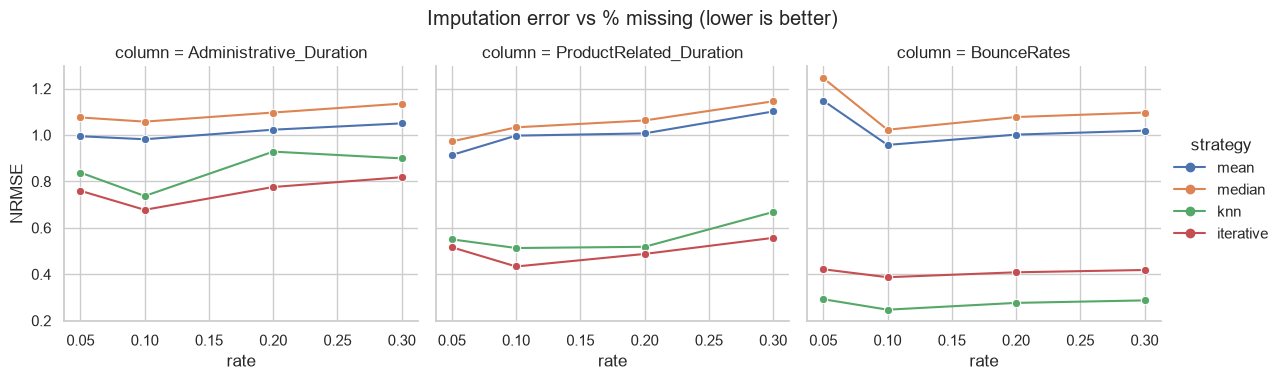

[saved] C:\Users\Vindiya\Documents\GitHub\Online-shoppers-purchase-intent\reports\figures\missing_A_nrmse.png


In [4]:
g = sns.relplot(data=num_res, x="rate", y="NRMSE", hue="strategy", col="column", kind="line",
                marker="o", height=3.6, aspect=1.1)
g.figure.suptitle("Imputation error vs % missing (lower is better)", y=1.05)
save_fig(g.figure, "missing_A_nrmse")

**Write down:** which strategy has the lowest error per column and why (e.g. BounceRates is strongly related to ExitRates, so KNN/iterative can use it; mean/median cannot). For `VisitorType`, mode accuracy equals the share of the majority class.

## 2B. Effect on model performance
For each strategy we cross-validate three models on the training data. `delete_incomplete_rows` shows what row deletion would cost.

In [5]:
zoo = get_models()
rows = []
for mname in ("LogisticRegression", "RandomForest", "HistGradientBoosting"):
    est = zoo[mname]
    for num in NUM_STRATEGIES:
        rows.append(cv_summary(build_pipeline(est, "class_weight", imputer=num, cat_imputer="mode"),
                               X_train, y_train, mname, scenario=f"impute_{num}+mode"))
    rows.append(cv_summary(build_pipeline(est, "class_weight", imputer="median", cat_imputer="unknown"),
                           X_train, y_train, mname, scenario="impute_median+Unknown_category"))
    keep = X_train.dropna().index
    rows.append(cv_summary(build_pipeline(est, "class_weight"), X_train.loc[keep], y_train.loc[keep], mname,
                           scenario=f"delete_incomplete_rows (n={len(keep)} of {len(X_train)})"))
resB = pd.DataFrame(rows)
cols = ["model", "scenario", "f1", "recall", "precision", "roc_auc", "pr_auc", "f1_std", "pr_auc_std"]
save_table(resB[cols], "missing_B_downstream")
resB[cols].round(4)

[saved] C:\Users\Vindiya\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\missing_B_downstream.csv


,model,scenario,f1,recall,precision,roc_auc,pr_auc,f1_std,pr_auc_std
0,LogisticRegression,impute_mean+mode,0.6510,0.8289,0.5362,0.9186,0.6639,0.0155,0.0258
1,LogisticRegression,impute_median+mode,0.6522,0.8296,0.5375,0.9186,0.6638,0.0167,0.0262
2,LogisticRegression,impute_knn+mode,0.6515,0.8290,0.5369,0.9187,0.6641,0.0163,0.0258
3,LogisticRegression,impute_iterative+mode,0.6505,0.8283,0.5358,0.9186,0.6644,0.0153,0.0260
4,LogisticRegression,impute_median+Unknown_category,0.6537,0.8309,0.5390,0.9185,0.6637,0.0163,0.0260
5,LogisticRegression,delete_incomplete_rows (n=7805 of 9790),0.6597,0.8265,0.5497,0.9175,0.6559,0.0125,0.0288
6,RandomForest,impute_mean+mode,0.6791,0.7424,0.6261,0.9294,0.7371,0.0156,0.0239
7,RandomForest,impute_median+mode,0.6818,0.7444,0.6293,0.9300,0.7394,0.0195,0.0216
8,RandomForest,impute_knn+mode,0.6813,0.7437,0.6290,0.9295,0.7375,0.0192,0.0225
9,RandomForest,impute_iterative+mode,0.6803,0.7405,0.6295,0.9298,0.7380,0.0219,0.0219


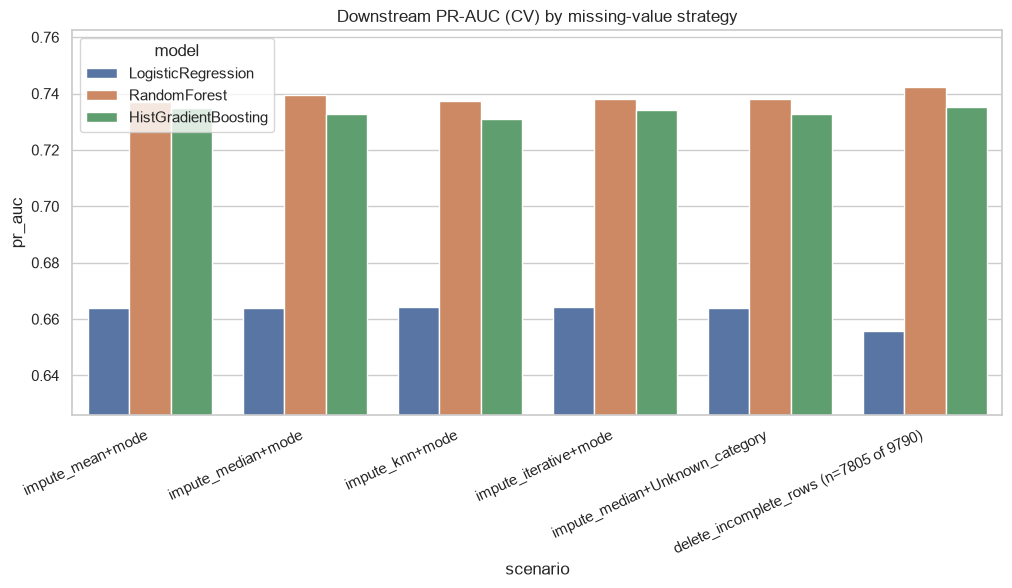

[saved] C:\Users\Vindiya\Documents\GitHub\Online-shoppers-purchase-intent\reports\figures\missing_B_downstream.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=resB, x="scenario", y="pr_auc", hue="model", ax=ax)
ax.set_ylim(resB["pr_auc"].min() - 0.03, resB["pr_auc"].max() + 0.02)
ax.set_title("Downstream PR-AUC (CV) by missing-value strategy")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
save_fig(fig, "missing_B_downstream")

**Write down:** differences between strategies downstream are usually small compared with the CV standard deviation (`*_std` columns) - say so honestly. The imputation error in 2A is where the strategies clearly differ. Row deletion discards ~20% of the data for no gain.

## 3. Outliers, feature engineering, feature selection, leakage (ablation)
One factor is changed at a time relative to `BEST_PREP`; the result is PR-AUC from stratified CV.

In [7]:
EXPERIMENTS = {
    "baseline (BEST_PREP)": {},
    "outlier: none": {"outlier": "none"},
    "outlier: log1p": {"outlier": "log"},
    "outlier: quantile cap": {"outlier": "cap"},
    "no feature engineering": {"use_fe": False},
    "with feature engineering": {"use_fe": True},
    "selector: mutual-info top30": {"selector": "kbest"},
    "selector: RF importance": {"selector": "rf"},
    "drop PageValues": {"drop_cols": ["PageValues"]},
    "drop PageValues+ExitRates+BounceRates": {"drop_cols": ["PageValues", "ExitRates", "BounceRates"]},
}
rows = []
for exp, override in EXPERIMENTS.items():
    prep = {**BEST_PREP, **override}
    for m in ("LogisticRegression", "RandomForest", "HistGradientBoosting"):
        print(f"{exp:40s} {m}")
        rows.append(cv_summary(build_pipeline(zoo[m], "class_weight", **prep), X_train, y_train, m, experiment=exp))
feat = pd.DataFrame(rows)
save_table(feat, "feature_experiments")
pivot = feat.pivot(index="experiment", columns="model", values="pr_auc").round(4)
save_table(pivot.reset_index(), "feature_experiments_pr_auc_pivot")
pivot

baseline (BEST_PREP)                     LogisticRegression
baseline (BEST_PREP)                     RandomForest
baseline (BEST_PREP)                     HistGradientBoosting
outlier: none                            LogisticRegression
outlier: none                            RandomForest
outlier: none                            HistGradientBoosting
outlier: log1p                           LogisticRegression
outlier: log1p                           RandomForest
outlier: log1p                           HistGradientBoosting
outlier: quantile cap                    LogisticRegression
outlier: quantile cap                    RandomForest
outlier: quantile cap                    HistGradientBoosting
no feature engineering                   LogisticRegression
no feature engineering                   RandomForest
no feature engineering                   HistGradientBoosting
with feature engineering                 LogisticRegression
with feature engineering                 RandomForest
with f

model,HistGradientBoosting,LogisticRegression,RandomForest
experiment,,,
baseline (BEST_PREP),0.7329,0.6638,0.7394
drop PageValues,0.3445,0.3280,0.3675
drop PageValues+ExitRates+BounceRates,0.3348,0.3109,0.3453
no feature engineering,0.7389,0.6620,0.7291
outlier: log1p,0.7329,0.6638,0.7394
outlier: none,0.7329,0.6663,0.7388
outlier: quantile cap,0.7343,0.6702,0.7408
selector: RF importance,0.7348,0.6628,0.7337
selector: mutual-info top30,0.7346,0.6648,0.7282


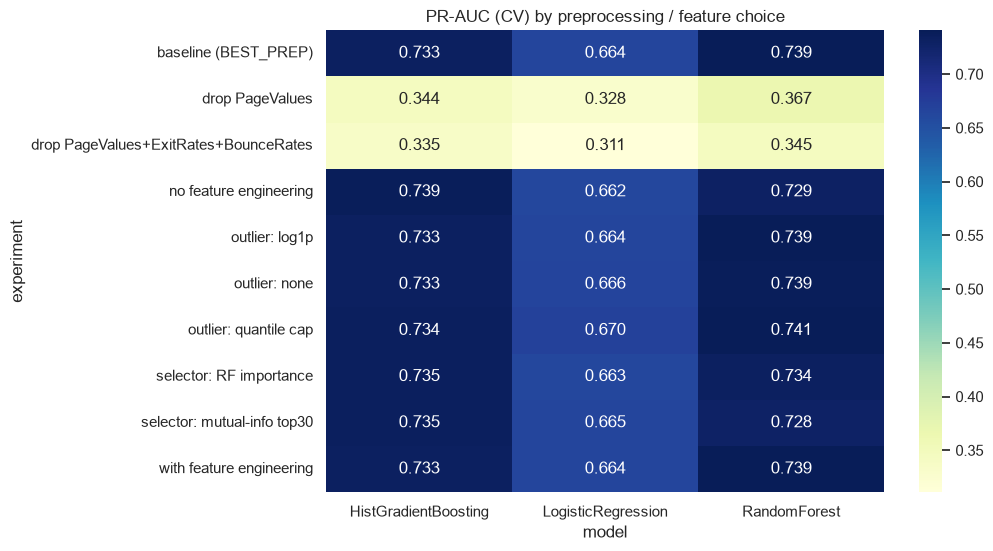

[saved] C:\Users\Vindiya\Documents\GitHub\Online-shoppers-purchase-intent\reports\figures\feature_experiments_heatmap.png


model,HistGradientBoosting,LogisticRegression,RandomForest
experiment,,,
baseline (BEST_PREP),0.770,0.830,0.744
drop PageValues,0.590,0.739,0.315
drop PageValues+ExitRates+BounceRates,0.568,0.697,0.288
no feature engineering,0.778,0.796,0.720
outlier: log1p,0.770,0.830,0.744
outlier: none,0.770,0.825,0.744
outlier: quantile cap,0.766,0.827,0.746
selector: RF importance,0.766,0.824,0.743
selector: mutual-info top30,0.771,0.824,0.739


In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax)
ax.set_title("PR-AUC (CV) by preprocessing / feature choice")
save_fig(fig, "feature_experiments_heatmap")
feat.pivot(index="experiment", columns="model", values="recall").round(3)

**Leakage decision:** compare `baseline` against `drop PageValues`. If PR-AUC collapses without it, the model relies heavily on a Google-Analytics value that partly encodes the purchase. Decide as a team whether the deployed system is used *after* the session (keep) or *during* it (drop), and write the reasoning in the report.

## 4. Decision
Open `src/preprocessing.py`, edit `BEST_PREP` (imputer, cat_imputer, outlier, use_fe, selector, drop_cols) with the choices you can justify from the tables above, commit, and **restart the kernel** before running notebook 03.
Then complete the `[RESULT]` cells in `reports/DECISIONS.md`.